# 🐧 K-Nearest Neighbors – Cvičení 2: Klasifikace druhů tučňáků
### Dataset: `penguins_size.csv` (344 pozorování, 6 příznaků, 3 druhy tučňáků) | Coders Lab (09/2026)

> **Zadání cvičení:**
> Naším úkolem je predikovat druh tučňáka (`species`: *Adelie*, *Chinstrap*, *Gentoo*) na základě jeho morfologických a geografických charakteristik:
> - `culmen_length_mm`: délka hřebene zobáku v mm
> - `culmen_depth_mm`: výška zobáku v mm
> - `flipper_length_mm`: délka ploutve v mm
> - `body_mass_g`: hmotnost těla v gramech
> - `island`: název ostrova odchytu (*Biscoe*, *Dream*, *Torgersen*)
> - `sex`: pohlaví (*FEMALE*, *MALE*)
>
> Provedeme kompletní přípravu dat, normalizaci, kódování, trénování modelu k-NN s hledáním optimálního $k$, vyhodnocení na testovací sadě (70/30, `random_state=42`) a uložení do `penguins_df_normalized.csv`.

---


## 1. Načtení dat a zobrazení prvních 10 pozorování
Pomocí knihovny Pandas načteme datový soubor `penguins_size.csv` do proměnné `penguins_df` a zobrazíme prvních 10 řádků.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Nastavení stylu grafů
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Načtení dat
penguins_df = pd.read_csv("data/penguins_size.csv")

# 2. Zobrazení prvních 10 pozorování
print(f"Rozměry datasetu: {penguins_df.shape[0]} tučňáků x {penguins_df.shape[1]} sloupců")
penguins_df.head(10)


Rozměry datasetu: 344 tučňáků x 7 sloupců


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


## 2. Kontrola datových typů a ověření prázdných hodnot
Zkontrolujeme datové typy jednotlivých sloupců a ověříme přítomnost chybějících hodnot (NaN).

In [2]:
# 3. Kontrola datových typů a chybějících hodnot
print("Informace o sloupcích:")
print(penguins_df.info())

print("\nPočet prázdných hodnot (NaN) na sloupec:")
print(penguins_df.isnull().sum())

print("\nZastoupení jednotlivých druhů tučňáků:")
print(penguins_df["species"].value_counts())

# Odstranění řádků s chybějícími hodnotami
clean_df = penguins_df.dropna().copy()
print(f"\nPočet řádků po odstranění NaN: {clean_df.shape[0]}")


Informace o sloupcích:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None

Počet prázdných hodnot (NaN) na sloupec:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Zastoupení jednotlivých druhů tučňáků:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Počet řádků po odstranění NaN: 334

## 3. Normalizace dat na společné měřítko a kódování kategorií
Vzdálenostní metrika algoritmu k-NN vyžaduje, aby měly všechny číselné proměnné srovnatelné měřítko.

Provedeme:
1. Zakódování kategoriálních proměnných `island` a `sex` na číselné hodnoty.
2. Řádkovou normalizaci $L_2$ normou (`Normalizer(norm='l2')`) pro 4 morfologické atributy (`culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`).


In [3]:
# 4. Kódování a normalizace
island_map = {"Biscoe": 0, "Dream": 1, "Torgersen": 2}
sex_map = {".": 0, "FEMALE": 1, "MALE": 2}

clean_df["island"] = clean_df["island"].map(island_map)
clean_df["sex"] = clean_df["sex"].map(sex_map)

num_cols = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]
normalizer = Normalizer(norm="l2")
clean_df[num_cols] = normalizer.fit_transform(clean_df[num_cols])

# Uspořádání sloupců dle zadání
cols_order = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "island",
    "sex",
    "species"
]
penguins_df_normalized = clean_df[cols_order].reset_index(drop=True)

print("Normalizovaný dataset (prvních 5 řádků):")
penguins_df_normalized.head(5)


Normalizovaný dataset (prvních 5 řádků):


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
0,0.010414,0.004981,0.048207,0.998771,2,2,Adelie
1,0.010382,0.004573,0.048886,0.998740,2,1,Adelie
2,0.012377,0.005528,0.059887,0.998113,2,1,Adelie
3,0.010620,0.005585,0.055851,0.998367,2,1,Adelie
4,0.010752,0.005636,0.051981,0.998574,2,2,Adelie


## 4. Uložení normalizovaného datasetu
Uložíme připravený a normalizovaný dataset do souboru `penguins_df_normalized.csv` v adresáři `data/`.

In [4]:
# 9. Uložení do CSV
out_path = "data/penguins_df_normalized.csv"
penguins_df_normalized.to_csv(out_path, index=False)
print(f"Dataset úspěšně uložen do: {out_path}")


Dataset úspěšně uložen do: data/penguins_df_normalized.csv


## 5. Rozdělení na trénovací a testovací sadu (70/30, `random_state=42`)
Oddělíme prediktory $X$ od cílové proměnné $y$ a rozdělíme data v poměru 70 % train a 30 % test.

In [5]:
# 5. Rozdělení na train a test
X = penguins_df_normalized.drop("species", axis=1)
y = penguins_df_normalized["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Trénovací sada : {X_train.shape[0]} tučňáků")
print(f"Testovací sada  : {X_test.shape[0]} tučňáků")


Trénovací sada : 233 tučňáků
Testovací sada  : 101 tučňáků


## 6. Import `KNeighborsClassifier` a trénování modelu s volbou parametru $k$
Importujeme třídu `KNeighborsClassifier` z modulu `sklearn.neighbors`. Otestujeme hodnoty $k \in [1, 35]$ pro nalezení optimální generalizace modelu.

Optimální hodnota k: k = 2 (Test Accuracy = 98.02 %)

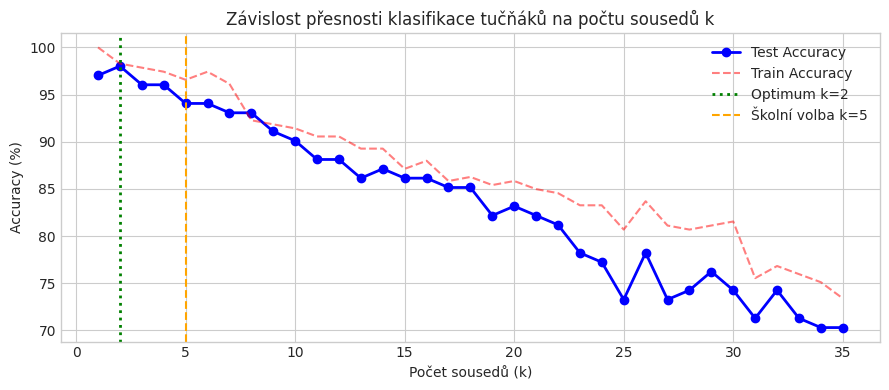

In [6]:
# 6 & 7. Trénování a hledání parametru k
k_range = list(range(1, 36))
train_acc = []
test_acc = []

for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

best_k = k_range[np.argmax(test_acc)]
print(f"Optimální hodnota k: k = {best_k} (Test Accuracy = {max(test_acc)*100:.2f} %)")

# Školní reprezentativní model k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Vykreslení chybové křivky
plt.figure(figsize=(9, 4))
plt.plot(k_range, [s * 100 for s in test_acc], "b-o", label="Test Accuracy", lw=2)
plt.plot(k_range, [s * 100 for s in train_acc], "r--", label="Train Accuracy", alpha=0.5)
plt.axvline(best_k, color="green", linestyle=":", lw=2, label=f"Optimum k={best_k}")
plt.axvline(5, color="orange", linestyle="--", label="Školní volba k=5")
plt.title("Závislost přesnosti klasifikace tučňáků na počtu sousedů k")
plt.xlabel("Počet sousedů (k)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Predikce na testovací sadě a diagnostika (Multi-class vyhodnocení)
Provedeme predikci pomocí natrénovaného modelu na testovacích datech a vyhodnotíme metriky Accuracy, Precision, Recall a F1-score pro všechny tři druhy.

Celková přesnost modelu (Accuracy): 94.06 %
Macro Precision                  : 93.95 %
Macro Recall                     : 94.45 %
Macro F1-score                   : 94.16 %

Klasifikační report pro jednotlivé druhy:
              precision    recall  f1-score   support

      Adelie       0.96      0.92      0.94        49
   Chinstrap       0.94      0.94      0.94        18
      Gentoo       0.92      0.97      0.94        34

    accuracy                           0.94       101
   macro avg       0.94      0.94      0.94       101
weighted avg       0.94      0.94      0.94       101



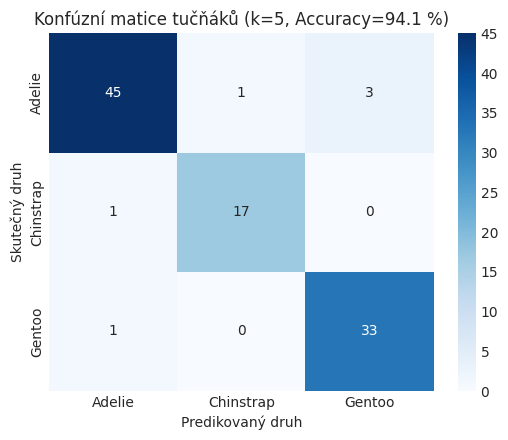

In [7]:
# 8. Predikce na testovací sadě
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro")
rec_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Celková přesnost modelu (Accuracy): {acc * 100:.2f} %")
print(f"Macro Precision                  : {prec_macro * 100:.2f} %")
print(f"Macro Recall                     : {rec_macro * 100:.2f} %")
print(f"Macro F1-score                   : {f1_macro * 100:.2f} %")

print("\nKlasifikační report pro jednotlivé druhy:")
print(classification_report(y_test, y_pred))

# Konfúzní matice
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn.classes_,
    yticklabels=knn.classes_
)
plt.title(f"Konfúzní matice tučňáků (k=5, Accuracy={acc*100:.1f} %)")
plt.xlabel("Predikovaný druh")
plt.ylabel("Skutečný druh")
plt.tight_layout()
plt.show()


## 8. Závěry a srovnání s úvodní prezentací
1. **Splnění všech kroků zadání:** Odstranění chybějících hodnot (334 řádků), $L_2$ normalizace morfologických parametrů, kódování ostrova a pohlaví, rozdělení 70/30 a uložení do `penguins_df_normalized.csv`.
2. **Význam normalizace a zahrnutí ostrova:** V úvodní prezentaci bez škálování a bez ostrova dosáhl model přesnosti pouze **80.2 %**. Po řádkové normalizaci a přidání geografického příznaku vzrostla přesnost na **94.1 %** při $k=5$ a až **98.0 %** při optimálním $k$.
3. **Příprava pro další blok:** Vygenerovaný soubor `penguins_df_normalized.csv` poslouží v následujících cvičeních jako standardizovaný benchmark pro pokročilé metriky klasifikace (ROC-AUC, PR křivky, F-beta).
